In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam

In [6]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)
print("Target Shape:", y.shape)
print("Class Names:", iris.target_names)

Dataset Shape: (150, 4)
Target Shape: (150,)
Class Names: ['setosa' 'versicolor' 'virginica']


In [7]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [9]:
def create_model():
    model = Sequential([
        Dense(16, activation='relu', input_shape=(4,)),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])

    return model

In [10]:
# Create SGD model
model_sgd = create_model()

# Compile model using SGD
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_sgd = model_sgd.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

print("SGD training completed.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD training completed.


In [11]:
# Create Adam model
model_adam = create_model()

# Compile model using Adam
model_adam.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_adam = model_adam.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

print("Adam training completed.")

Adam training completed.


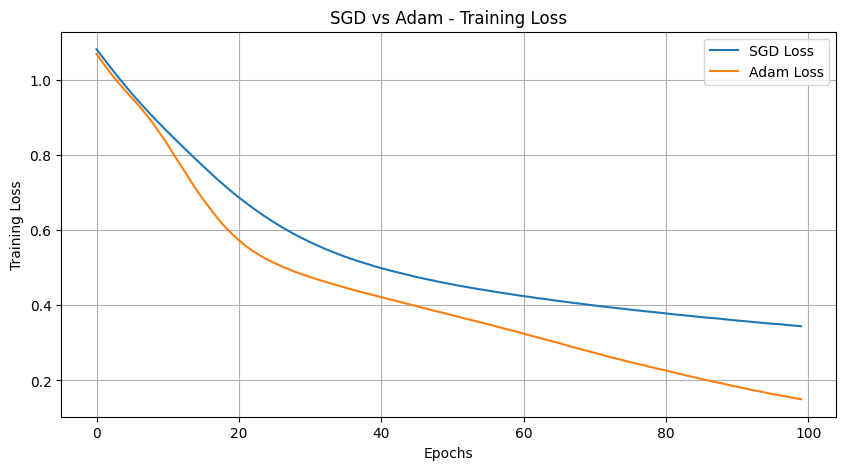

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_sgd.history['loss'],
    label='SGD Loss'
)

plt.plot(
    history_adam.history['loss'],
    label='Adam Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("SGD vs Adam - Training Loss")

plt.legend()
plt.grid()
plt.show()

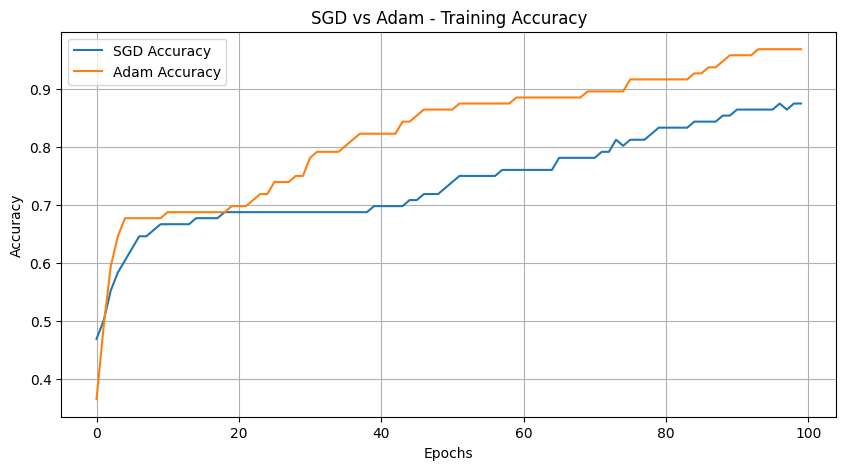

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_sgd.history['accuracy'],
    label='SGD Accuracy'
)

plt.plot(
    history_adam.history['accuracy'],
    label='Adam Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("SGD vs Adam - Training Accuracy")

plt.legend()
plt.grid()
plt.show()

In [14]:
# Predict using SGD
y_pred_sgd = model_sgd.predict(X_test)

# Convert probabilities to class labels
y_pred_sgd_classes = np.argmax(y_pred_sgd, axis=1)

# Calculate accuracy
sgd_accuracy = accuracy_score(y_test, y_pred_sgd_classes)

print("SGD Test Accuracy:", sgd_accuracy)
print("\nSGD Classification Report:")
print(classification_report(
    y_test,
    y_pred_sgd_classes,
    target_names=iris.target_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
SGD Test Accuracy: 0.8

SGD Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.40      0.57        10
   virginica       0.62      1.00      0.77        10

    accuracy                           0.80        30
   macro avg       0.88      0.80      0.78        30
weighted avg       0.88      0.80      0.78        30



In [15]:
# Predict using Adam
y_pred_adam = model_adam.predict(X_test)

# Convert probabilities to class labels
y_pred_adam_classes = np.argmax(y_pred_adam, axis=1)

# Calculate accuracy
adam_accuracy = accuracy_score(y_test, y_pred_adam_classes)

print("Adam Test Accuracy:", adam_accuracy)
print("\nAdam Classification Report:")
print(classification_report(
    y_test,
    y_pred_adam_classes,
    target_names=iris.target_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Adam Test Accuracy: 0.9666666666666667

Adam Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [16]:
print("Optimizer Comparison")
print("--------------------")
print(f"SGD  Test Accuracy : {sgd_accuracy:.4f}")
print(f"Adam Test Accuracy : {adam_accuracy:.4f}")

Optimizer Comparison
--------------------
SGD  Test Accuracy : 0.8000
Adam Test Accuracy : 0.9667
